# 02 · Predict a review's rating (regression)

**Use case.** The support team wants a predicted star rating for every review as it arrives — from its text, its summary and the product it is about — as a number they can rank on, not a class.

**Model / lane:** relational GNN — the default GraphSAGE architecture (Langsat labels it *Baseline*), text embeddings on `review_text`, `summary`, `product.title` / `description`

**What you will learn**
1. Create a `data_science` project on the three tables (no clean step — the training pipeline cleans)
2. Define the task in plain English and read the config Langsat derived
3. Train a relational GNN with text embeddings, watch the run
4. Read the test metrics — MAE, RMSE, R², Spearman — against an always-the-mean baseline
5. See the Model tab as images: overview, feature importance, training curves, MAE/RMSE per epoch
6. Rank every review by predicted rating, score one on demand, look at residuals

**What this costs.** one GPU training run (a few minutes on `g4dn.2xlarge`; the API reserves the estimate — about 8,700 credits on the Team plan — and refunds the unused minutes, so a 90-second run ends up costing a few hundred), plus 50 credits per on-demand prediction. A re-run that finds the finished model pays only for its predictions.

> Every cell below ran for real against `api.langsat.ai` — the outputs are what the API returned. Re-running is safe:
> projects are found by name and reused, and a finished model is not retrained.

In [1]:
import sys, json
sys.path.insert(0, "..")
from _common import connect, get_or_create_project, print_schema, train_or_reuse, credits_used, save_metrics, show, fig, metrics_table, project_models
from langsat import viz
import pandas as pd

ls = connect()

signed in as team@langsat.ai · tier team · key 'TEST-SDK-4' with 20 scopes


In [2]:
p = get_or_create_project(ls, "rating-regression", kind="data_science")
before = credits_used(ls)

reusing project 8847cd90-8444-4934-aad9-8faa372216bf (amazon-reviews-rating-regression, status=ready)
project ready: status=ready · type=data_science · files=['customer.csv', 'product.csv', 'review.csv']


## Define the task, train

The task is one sentence. `train_or_reuse` prints the config Langsat derived (entity table, target, which text columns get embedded), the estimate, then polls the run and reuses a finished model on re-runs. `task_type="supervised"` + `subtask_type="regression"` pins the flavour; leave both out and Langsat classifies the intent itself.

In [3]:
model = train_or_reuse(p, "Predict the rating a review gives, from the review text, its summary and the product it is about",
                       task_type="supervised", subtask_type="regression", enable_text_embedding=True)
metrics = model["metrics"]
show(metrics)

reusing model 927511dc-161d-4a92-ac2b-6e3b97a0c9fc (Baseline, trained 2026-09-16T02:20:13.269852+00:00)
  r2                     0.4816
  mae                    0.476
  rmse                   0.6621
  mae_zero               4.463
  spearman               0.5356
  mae_median             0.537
  lift_at_1pct           1.1203
  lift_at_5pct           1.1091
  lift_at_10pct          1.1058
  lift_at_0.1pct         1.1203
  lift_base_rate         4.463


## Baseline

Always predicting the mean rating: what a model must beat. On 10,000 heavily 5★-skewed reviews the *ranking* metric is the one to read — a Spearman of ~0.5 means the model orders reviews from worst to best far better than chance even where the absolute star value is off by half a star.

In [4]:
review = p.table("review").to_pandas()
mean = review["rating"].mean()
baseline_mae = (review["rating"] - mean).abs().mean()
baseline_rmse = ((review["rating"] - mean) ** 2).mean() ** 0.5
print(f"always-mean baseline · MAE {baseline_mae:.3f} · RMSE {baseline_rmse:.3f} · R² 0.000")
print(f"model (test split)    · MAE {metrics.get('mae'):.3f} · RMSE {metrics.get('rmse'):.3f} · R² {metrics.get('r2'):.3f} · Spearman {metrics.get('spearman', float('nan')):.3f}")

always-mean baseline · MAE 0.770 · RMSE 0.980 · R² 0.000
model (test split)    · MAE 0.476 · RMSE 0.662 · R² 0.482 · Spearman 0.536


## The Model tab, as images

After training the app builds a **Model** tab: overview, feature importance, training curves and the task-specific
cards. It is a normal dashboard tab whose widgets carry Plotly JSON, so `viz.model_dashboard(p)` draws exactly what the
app shows — and `viz.model_cards(p)` lets you pick one card. The Model Overview table carries numbers the API's
`metrics` dict does not (they live only in the trained model's metadata).

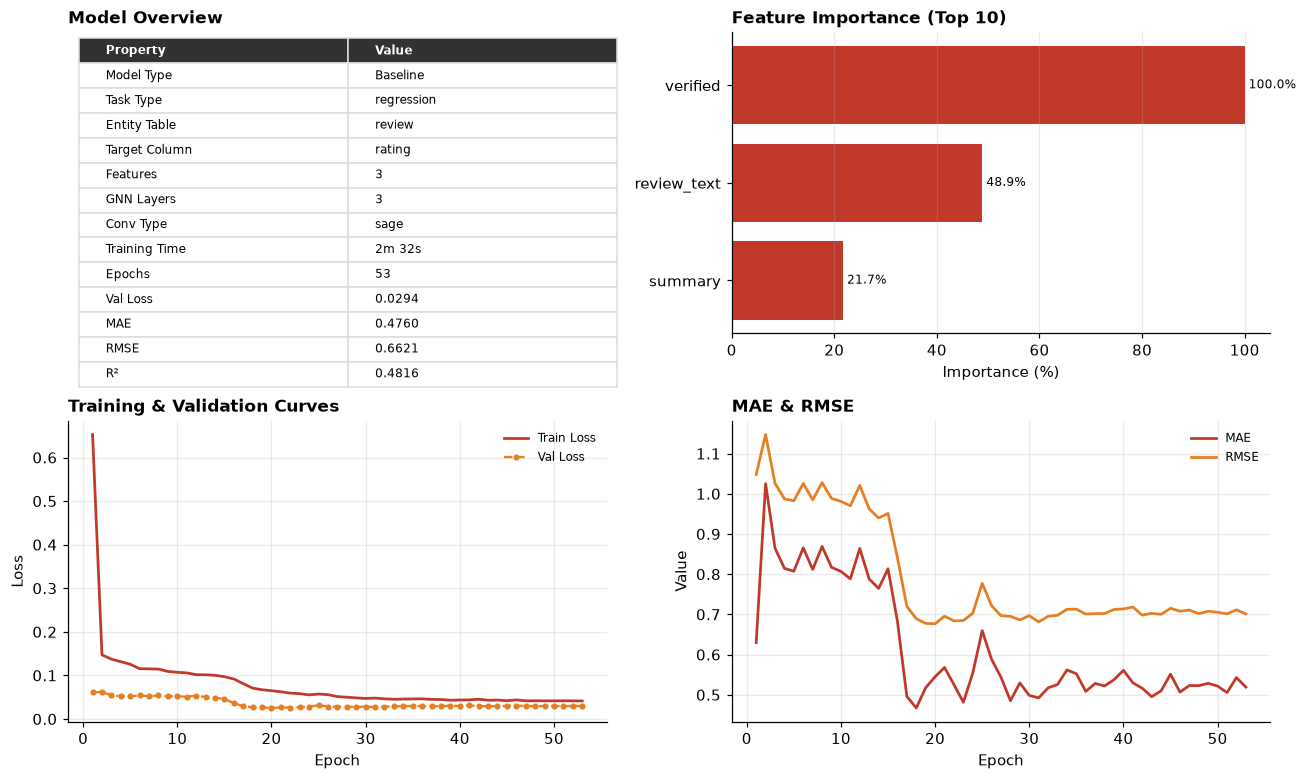

In [5]:
fig(viz.model_dashboard(p, cols=2))

In [6]:
cards = viz.model_cards(p)
overview = viz.card_table(cards["Model Overview"])
{k: overview[k] for k in list(overview)[:12]}

{'Model Type': 'Baseline',
 'Task Type': 'regression',
 'Entity Table': 'review',
 'Target Column': 'rating',
 'Features': '3',
 'GNN Layers': '3',
 'Conv Type': 'sage',
 'Training Time': '2m 32s',
 'Epochs': '53',
 'Val Loss': '0.0294',
 'MAE': '0.4760',
 'RMSE': '0.6621'}

The training run's epoch history is also on `GET /projects/{id}/status` — the numbers behind the curves, as a table.

In [7]:
hist = pd.DataFrame(p.pipeline_status().get("epoch_history") or [])
hist[["epoch", "train_loss", "val_loss", "epoch_time_sec"]].tail(5)

,epoch,train_loss,val_loss,epoch_time_sec
210,50,0.043243,0.174515,0.35
211,51,0.043537,0.161932,0.35
212,52,0.042182,0.168725,0.35
213,53,0.041284,0.165630,0.35
214,54,0.040734,0.170238,0.35


## Rank, score, explain

`predict.top` ranks every review by its stored predicted rating; `order="asc"` gives the other end. `predict.predict` scores one entity on demand (50 credits). Joining the two ends back to the review table shows what the model thinks a bad and a good review look like.

In [8]:
best = ls.predict.top(model["model_id"], n=50)
worst = ls.predict.top(model["model_id"], n=50, order="asc")
print("ranked by:", best.get("ranked_by"), "· total ranked:", best.get("total_ranked"))
ends = pd.DataFrame([{"entity_id": r["entity_id"], "predicted": r["score"], "end": "top 50"} for r in best["ranking"]] +
                    [{"entity_id": r["entity_id"], "predicted": r["score"], "end": "bottom 50"} for r in worst["ranking"]])
joined = ends.merge(review.reset_index().rename(columns={"index": "entity_id"}), on="entity_id", how="left")
print(joined.groupby("end")[["predicted", "rating"]].mean().round(2))
joined[["end", "predicted", "rating", "summary"]].head(6)

ranked by: score · total ranked: 2000
           predicted  rating
end                         
bottom 50       1.47    2.20
top 50          4.94    4.96


,end,predicted,rating,summary
0,top 50,4.995183,5,fantastic!!!
1,top 50,4.985507,5,Five Stars
2,top 50,4.973538,5,5 stars!!!
3,top 50,4.968118,5,This is one of my favorite books to read with ...
4,top 50,4.964913,5,I LOVE IT!
5,top 50,4.962090,5,"A must read for everyone, especially Veterans"


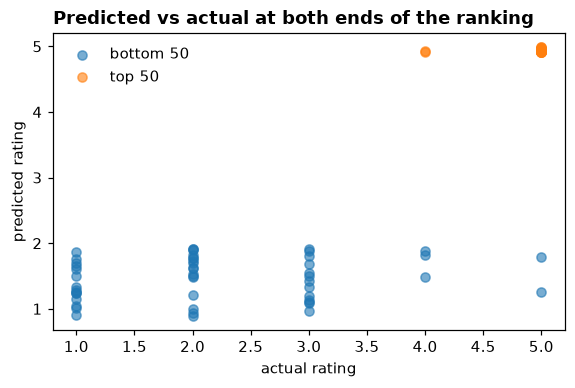

In [9]:
import matplotlib.pyplot as plt
f, ax = plt.subplots(figsize=(6, 3.5))
for end, grp in joined.groupby("end"):
    ax.scatter(grp["rating"], grp["predicted"], alpha=0.6, label=end)
ax.set_xlabel("actual rating"); ax.set_ylabel("predicted rating"); ax.legend(frameon=False)
ax.set_title("Predicted vs actual at both ends of the ranking", loc="left", fontweight="bold"); fig(f)

In [10]:
one = ls.predict.predict(model_id=model["model_id"], entity_id=best["ranking"][0]["entity_id"])
print("predicted rating:", round(one["result"]["prediction"], 3), "· task:", one["task_type"], "· model:", one["version_label"])

predicted rating: 4.995 · task: regression · model: v3


In [11]:
charged = credits_used(ls) - before
save_metrics(".", {"notebook": "02_rating_regression", "task": "regression · review.rating", "model": model.get("model_type"),
                   "project_id": p.id, "model_id": model["model_id"], "training_duration_sec": model.get("training_duration_sec"),
                   "credits_charged_this_run": charged,
                   "headline": {"mae": metrics.get("mae"), "rmse": metrics.get("rmse"), "r2": metrics.get("r2"), "spearman": metrics.get("spearman")},
                   "baseline": {"mae": round(baseline_mae, 4), "rmse": round(baseline_rmse, 4), "r2": 0.0}})

wrote results/metrics.json


PosixPath('results/metrics.json')

## Where to go next

- [03 · Rating classification](../03_rating_classification/) — the same target as five classes, another architecture
- [12 · Training options](../12_training_options/) — text embeddings on/off and the architecture bake-off, on this project
- [11 · Fine-tune](../11_finetune/) — new reviews arrive; continue this model instead of retraining